Partie 1 – Exploration du corpus
1) Charger les données CSV ;

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("../data/smart_reviews_raw.csv")

2) Combien d'avis contient le dataset ?

In [114]:
df.shape[0]

1200

3) Combien de colonnes possède-t-il ?

In [115]:
df.shape[1]

8

4) Quel est le type de chaque colonne ?

In [116]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

5) Existe-t-il des valeurs manquantes ?

In [117]:
df.isnull().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec
répétition de caractères.

Texte normal

In [118]:
import re

textes = df["texte"].astype(str)

print("Exemples de textes normaux :")

compteur = 0

for texte in textes:
    if (
        texte.strip()
        and not re.search(r"https?://|www\.", texte)
        and not re.search(r"@\w+", texte)
        and not re.search(r"#\w+", texte)
    ):
        print("-", texte)
        compteur += 1
        
        if compteur == 5:
            break

Exemples de textes normaux :
- Très  bonne  expérience,  simple  et  efficace.
- Produit  parfait,  rien  à  signaler.
- Produit excellent, je suis très satisfait. !!!
- LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
- Très satisfait de mon achat 👍 😊


Texte vide

In [119]:
textes_vides = df[df["texte"].fillna("").astype(str).str.strip() == ""]

print("Nombre de textes vides :", len(textes_vides))

textes_vides.head(8)

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr


Texte contenant une URL

In [120]:
mask_url = textes.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

textes_url = df[mask_url]

print("Nombre de textes contenant une URL :", len(textes_url))

textes_url[["texte"]].head()

Nombre de textes contenant une URL : 143


,texte
16,"Produit parfait, rien à signaler. https://exam..."
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam..."
35,"Très bon produit, la qualité est au rendez-vou..."


Texte contenant une mention

In [121]:
mask_mention = textes.str.contains(
    r"@\w+",
    regex=True
)

textes_mentions = df[mask_mention]

print("Nombre de textes contenant une mention :", len(textes_mentions))

textes_mentions[["texte"]].head()

Nombre de textes contenant une mention : 128


,texte
9,@client Livraison rapide et produit conforme à...
32,@client Service client réactif et commande reç...
40,@client La qualité est correcte sans être exce...
44,"@client Je recommande vivement, tout fonctionn..."
45,@client Excellent rapport qualité-prix.


Texte contenant un hashtag

In [122]:
mask_hashtag = textes.str.contains(
    r"#\w+",
    regex=True
)

textes_hashtags = df[mask_hashtag]

print("Nombre de textes contenant un hashtag :", len(textes_hashtags))

textes_hashtags[["texte"]].head()

Nombre de textes contenant un hashtag : 127


,texte
1,Très satisfait de mon achat 👍 #avis
12,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis
38,"Très bonne expérience, simple et efficace. #avis"
69,La batterie tient vraiment bien et l'écran est...


Textes contenant des emojis

In [123]:
# Création d'une expression régulière permettant de détecter les emojis
emoji_pattern = re.compile(

    # Début de la liste des caractères recherchés
    "["
    
    # Emojis et symboles divers
    "\U0001F300-\U0001F5FF"
    
    # Émoticônes et visages
    "\U0001F600-\U0001F64F"
    
    # Moyens de transport et symboles
    "\U0001F680-\U0001F6FF"
    
    # Symboles supplémentaires
    "\U0001F700-\U0001F77F"
    
    # Symboles supplémentaires
    "\U0001F780-\U0001F7FF"
    
    # Symboles supplémentaires
    "\U0001F800-\U0001F8FF"
    
    # Emojis récents et symboles
    "\U0001F900-\U0001F9FF"
    
    # Emojis et symboles récents
    "\U0001FA00-\U0001FAFF"
    
    # Symboles divers comme ⭐, ✨, ❤️, etc.
    "\U00002700-\U000027BF"
    
    # Fin de la liste des caractères recherchés
    "]+",

    # Permet de gérer correctement les caractères Unicode, notamment les emojis
    flags=re.UNICODE
)

# Parcourt chaque texte et vérifie s'il contient au moins un emoji
# bool(...) transforme le résultat en True (emoji trouvé) ou False (aucun emoji)
mask_emoji = textes.apply(lambda x: bool(emoji_pattern.search(x)))

# Sélectionne uniquement les lignes du DataFrame correspondant
# aux textes qui contiennent au moins un emoji
textes_emojis = df[mask_emoji]

# Affiche le nombre de textes contenant des emojis
print("Nombre de textes contenant des emojis :", len(textes_emojis))

# Affiche les 5 premiers textes contenant des emojis
textes_emojis[["texte"]].head()

Nombre de textes contenant des emojis : 192


,texte
1,Très satisfait de mon achat 👍 #avis
5,Très satisfait de mon achat 👍 😊
7,Très satisfait de mon achat 👍
10,Très satisfait de mon achat 👍 !!!
19,"Je viens de recevoir le produit, à voir dans l..."


Textes avec beaucoup de ponctuation

In [124]:
import string

def nombre_ponctuation(texte):
    return sum(1 for caractere in texte if caractere in string.punctuation)

ponctuation = textes.apply(nombre_ponctuation)

print("Exemples de textes avec beaucoup de ponctuation :")

df.loc[ponctuation >= 5, ["texte"]].head()

Exemples de textes avec beaucoup de ponctuation :


,texte
3,"Produit excellent, je suis très satisfait. !!!"
16,"Produit parfait, rien à signaler. https://exam..."
25,"Produit reçu endommagé, je suis mécontent. !!!"
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."


Textes en majuscules

In [125]:
def est_majuscules(texte):
    lettres = [c for c in texte if c.isalpha()]
    
    if len(lettres) == 0:
        return False
    
    return sum(c.isupper() for c in lettres) / len(lettres) >= 0.8

mask_majuscules = textes.apply(est_majuscules)

textes_majuscules = df[mask_majuscules]

print("Nombre de textes en majuscules :", len(textes_majuscules))

textes_majuscules[["texte"]].head()

Nombre de textes en majuscules : 146


,texte
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
17,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
23,"PRODUIT EXCELLENT, JE SUIS TRÈS SATISFAIT."
24,TRÈS SATISFAIT DE MON ACHAT 👍


Textes avec répétition de caractères

In [126]:
mask_repetition = textes.str.contains(
    r"(.)\1{2,}",
    regex=True
)

textes_repetition = df[mask_repetition]

print(
    "Nombre de textes avec répétition de caractères :",
    len(textes_repetition)
)

textes_repetition[["texte"]].head(5)

Nombre de textes avec répétition de caractères : 165


C:\Users\UNiK\AppData\Local\Temp\ipykernel_5264\1974043422.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_repetition = textes.str.contains(


,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
28,"Produit excellent, je suis trèèès satisfait."


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer :
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

Mesurer la longueur des textes

In [127]:
df["longueur"] = df["texte"].fillna("").astype(str).str.len()
df[["texte", "longueur"]].head()

,texte,longueur
0,"Très bonne expérience, simple et efficace.",47
1,Très satisfait de mon achat 👍 #avis,35
2,"Produit parfait, rien à signaler.",37
3,"Produit excellent, je suis très satisfait. !!!",46
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,55


Longueur minimale

In [128]:
longueur_min = df["longueur"].min()

print("Longueur minimale :", longueur_min)

Longueur minimale : 0


Longueur maximale

In [129]:
longueur_max = df["longueur"].max()

print("Longueur maximale :", longueur_max)

Longueur maximale : 636


Longueur moyenne

In [130]:
longueur_moyenne = df["longueur"].mean()

print("Longueur moyenne :", longueur_moyenne)

Longueur moyenne : 48.96333333333333


determiner la Médiane

In [131]:
mediane = df["longueur"].median()

print("Médiane :", mediane)

Médiane : 48.0


Quartiles

In [132]:
quartiles = df["longueur"].quantile([0.25, 0.50, 0.75])

print(quartiles)

0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


8) Visualiser la distribution de la longueur des avis puis répondre aux questions

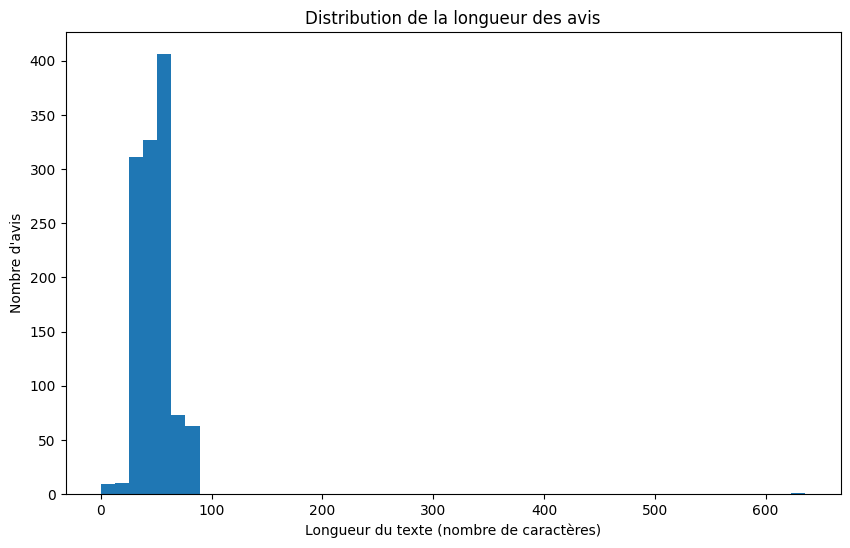

In [133]:
plt.figure(figsize=(10, 6))

plt.hist(df["longueur"], bins=50)

plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur du texte (nombre de caractères)")
plt.ylabel("Nombre d'avis")

plt.show()

a) Existe-t-il des textes anormalement longs ?

In [134]:
Q1 = df["longueur"].quantile(0.25)
Q3 = df["longueur"].quantile(0.75)

IQR = Q3 - Q1

seuil_long = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Seuil des textes anormalement longs :", seuil_long)

Q1 : 37.0
Q3 : 56.0
IQR : 19.0
Seuil des textes anormalement longs : 84.5


In [135]:
textes_tres_longs = df[df["longueur"] > seuil_long]

print(
    "Nombre de textes anormalement longs :",
    len(textes_tres_longs)
)

Nombre de textes anormalement longs : 41


In [136]:
textes_tres_longs[["texte", "longueur"]].head(10)

,texte,longueur
31,"Je viens de recevoir le produit, à voir dans l...",86
51,"Je viens de recevoir le produit, à voir dans l...",86
110,La batterie tient vraiment bien et l'écran est...,88
123,Service client réactif et commande reçue rapid...,85
145,Livraison rapide et produit conforme à mes att...,85
294,"Je recommande vivement, tout fonctionne parfai...",86
306,"Je viens de recevoir le produit, à voir dans l...",87
313,"Je viens de recevoir le produit, à voir dans l...",87
318,La batterie tient vraiment bien et l'écran est...,88
340,"Je viens de recevoir le produit, à voir dans l...",87


In [137]:
df.shape[0]

1200

Le dataset contient 1 200 avis, dont 41 sont identifiés comme anormalement longs selon la méthode de l’IQR. Cela représente environ 3,42 % des observations. Ces textes sont donc minoritaires dans le corpus, mais ils devront être examinés afin de vérifier s’ils correspondent à de véritables avis longs ou à des anomalies de données

b) Existe-t-il beaucoup de textes très courts ?

In [138]:
textes_tres_courts = df[df["longueur"] < 10]

print(
    "Nombre de textes très courts (< 10 caractères) :",
    len(textes_tres_courts)
)

Nombre de textes très courts (< 10 caractères) : 9


In [139]:
#afficher quelques exemples
textes_tres_courts[["texte", "longueur"]].head(20)

,texte,longueur
46,NaN,0
108,NaN,0
224,OK,2
310,NaN,0
554,Pas bon,7
640,NaN,0
781,NaN,0
889,OK,2
951,,3


9) Détecter les textes vides

In [140]:
textes_vides = df[
    df["texte"].isna() |
    (df["texte"].fillna("").astype(str).str.strip() == "")
]

print("Nombre de textes vides :", len(textes_vides))

Nombre de textes vides : 6


In [141]:
textes_vides[["id_avis", "texte"]].head(10)

,id_avis,texte
46,AV0047,NaN
108,AV0109,NaN
310,AV0311,NaN
640,AV0641,NaN
781,AV0782,NaN
951,AV0952,


10) Détecter les doublons sur le texte

In [142]:
doublons = df["texte"].duplicated().sum()

print("Nombre de textes en doublon :", doublons)

Nombre de textes en doublon : 881


11) Les classes sont-elles équilibrées ?

In [143]:
print(df["sentiment"].value_counts())

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64


Les classes ne sont pas équilibrées. La classe « positif » est largement majoritaire avec 776 avis. Elle est suivie de la classe « neutre » avec 246 avis  et de la classe « negatif » avec 178 avis. Il existe donc un déséquilibre important entre les classes, notamment entre la classe positive et les classes neutre et négative.

12) Quelle est la classe majoritaire ?

In [144]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
effectif_majoritaire = df["sentiment"].value_counts().max()

print("Classe majoritaire :", classe_majoritaire)
print("Nombre d'avis :", effectif_majoritaire)

Classe majoritaire : positif
Nombre d'avis : 776


13) Quelles métriques de classification à envisager d’utiliser ?

Pour évaluer le modèle de classification, j'envisage d'utiliser l'accuracy, la précision, le rappel et le F1-score. La matrice de confusion permettra également d'identifier les erreurs entre les différentes classes de sentiment. En cas de déséquilibre entre les classes, le F1-score et les métriques par classe seront particulièrement importants.

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; …

Emojis

In [145]:
mask_emoji = textes.apply(lambda x: bool(emoji_pattern.search(x)))

print("Textes contenant des emojis :", mask_emoji.sum())

Textes contenant des emojis : 192


URLs

In [146]:
mask_url = textes.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

print("Textes contenant des URLs :", mask_url.sum())

Textes contenant des URLs : 143


Hashtags

In [147]:

mask_hashtag = textes.str.contains(
    r"#\w+",
    regex=True
)

print("Textes contenant des hashtags :", mask_hashtag.sum())

Textes contenant des hashtags : 127


Mentions

In [148]:

mask_mention = textes.str.contains(
    r"@\w+",
    regex=True
)

print("Textes contenant des mentions :", mask_mention.sum())

Textes contenant des mentions : 128


chiffres

In [149]:

mask_chiffres = textes.str.contains(
    r"\d",
    regex=True
)

print("Textes contenant des chiffres :", mask_chiffres.sum())

Textes contenant des chiffres : 142


Caractères spéciaux

In [150]:
mask_caracteres_speciaux = textes.str.contains(
    r"[^a-zA-ZÀ-ÿ0-9\s]",
    regex=True
)

print(
    "Textes contenant des caractères spéciaux :",
    mask_caracteres_speciaux.sum()
)

Textes contenant des caractères spéciaux : 1190


ponctuations répétées

In [151]:
mask_ponctuation_rep = textes.str.contains(
    r"([!?.,;:])\1{1,}",
    regex=True
)

print(
    "Textes contenant une ponctuation répétée :",
    mask_ponctuation_rep.sum()
)

Textes contenant une ponctuation répétée : 141


C:\Users\UNiK\AppData\Local\Temp\ipykernel_5264\243762555.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_ponctuation_rep = textes.str.contains(


15) Visualiser et commenter nombre d'avis par source

In [152]:
avis_par_source = df["source"].value_counts()

print(avis_par_source)

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


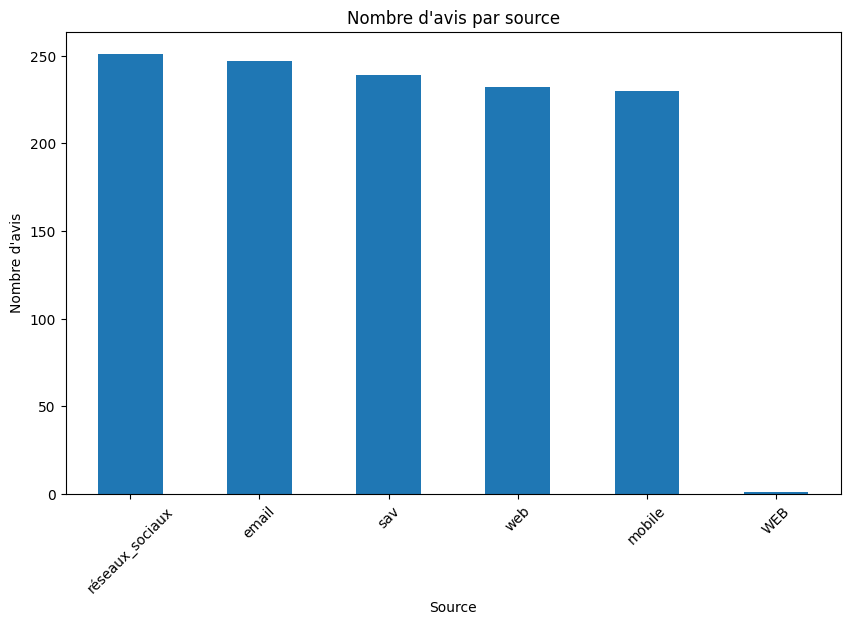

In [153]:
plt.figure(figsize=(10, 6))

avis_par_source.plot(kind="bar")

plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)

plt.show()

La répartition des avis varie selon les sources. Le site web représente la source la moins importante du corpus, tandis que certaines autres sources sont plus représentées. Cette différence doit être prise en compte lors de l'analyse afin d'éviter de généraliser les résultats à partir d'une seule source.

16) Visualiser et commenter le nombre d'avis par produit

In [154]:
avis_par_produit = df["produit"].value_counts()

print(avis_par_produit)

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


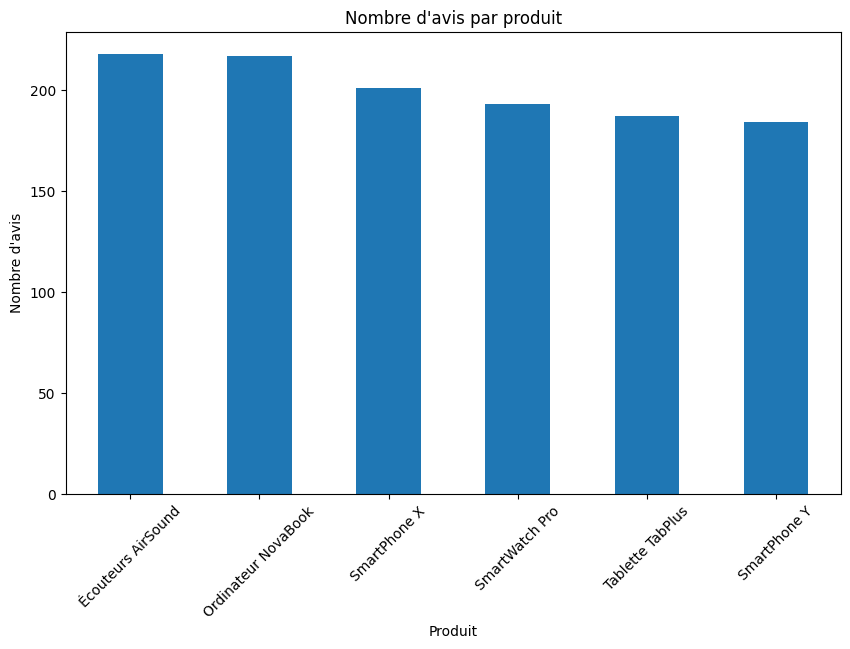

In [155]:
plt.figure(figsize=(10, 6))

avis_par_produit.plot(kind="bar")

plt.title("Nombre d'avis par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)

plt.show()

La répartition des avis par produit est relativement équilibrée. Le nombre d'avis varie de 184 à 218 selon les produits. Écouteurs AirSound est le produit ayant reçu le plus d'avis avec 218, tandis que SmartPhone Y en compte le moins avec 184. L'écart entre ces deux produits reste faible, avec seulement 34 avis de différence. Aucun produit ne domine donc fortement le corpus.

Partie 2 – Nettoyage
1) Supprimer les lignes contenant des valeurs manquantes de texte

In [156]:
# Supprimer les lignes dont la colonne texte est vide (NaN)
df = df.dropna(subset=["texte"])

print("Nombre d'avis après suppression des valeurs manquantes :", len(df))

Nombre d'avis après suppression des valeurs manquantes : 1195


2) Supprimer les doublons

In [157]:
df = df.drop_duplicates(subset=["texte"])

print("Nombre d'avis après suppression des doublons :", len(df))

Nombre d'avis après suppression des doublons : 318


3) Supprimer les URLs

In [158]:
import re

df["texte_clean"] = df["texte"].astype(str)

df["texte_clean"] = df["texte_clean"].str.replace(
    r"https?://\S+|www\.\S+",
    "",
    regex=True
)

df[["texte", "texte_clean"]].head()

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 #avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de sentiment

In [159]:
df["texte_clean"] = df["texte_clean"].str.replace(
    r"[@#](\w+)",
    r"\1",
    regex=True
)

df[["texte", "texte_clean"]].head()

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


5) Nettoyer les espaces

In [160]:
df["texte_clean"] = df["texte_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
)

df["texte_clean"] = df["texte_clean"].str.strip()

df[["texte", "texte_clean"]].head()

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment

In [161]:
df["texte_clean"] = df["texte_clean"].str.replace(
    r"[^\w\sÀ-ÿ]",
    " ",
    regex=True
)

df["texte_clean"] = df["texte_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

df[["texte", "texte_clean"]].head()

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...


7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus

In [162]:
import re

def nettoyer_texte(texte):
    # Convertir en chaîne de caractères
    texte = str(texte)
    
    # Supprimer les URLs
    texte = re.sub(r"https?://\S+|www\.\S+", "", texte)
    
    # Supprimer le symbole # des hashtags mais conserver le mot
    texte = re.sub(r"#(\w+)", r"\1", texte)
    
    # Supprimer le symbole @ des mentions mais conserver le nom
    texte = re.sub(r"@(\w+)", r"\1", texte)
    
    # Supprimer la ponctuation
    texte = re.sub(r"[^\w\sÀ-ÿ]", " ", texte)
    
    # Remplacer les espaces multiples par un seul espace
    texte = re.sub(r"\s+", " ", texte)
    
    # Supprimer les espaces au début et à la fin
    texte = texte.strip()
    
    return texte

8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [163]:
df["texte_clean"] = df["texte"].apply(nettoyer_texte)


9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations

In [164]:
df[["texte", "texte_clean"]].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la descrip...
9,@client Livraison rapide et produit conforme à...,client Livraison rapide et produit conforme à ...


Partie 3 – Tokenisation
1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

split() sépare simplement le texte selon les espaces. Il ne prend pas correctement en compte les particularités du langage naturel comme la ponctuation, les contractions, les mots composés ou certains caractères particuliers.

Pour une vraie application NLP, on utilise donc une bibliothèque spécialisée comme NLTK, qui possède des outils de tokenisation adaptés au traitement automatique du langage.

2) Utiliser la bibliothèque NLTK pour déterminer :
a) le nombre de tokens de chaque texte,

In [165]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [166]:
import nltk

telecharger le tokenisation necessaire

In [167]:
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\UNiK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\UNiK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

a) le nombre de tokens de chaque texte,


In [168]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["texte_clean"].apply(word_tokenize)

df["nombre_tokens"] = df["tokens"].apply(len)

df[["texte_clean", "tokens", "nombre_tokens"]].head(10)

,texte_clean,tokens,nombre_tokens
0,Très bonne expérience simple et efficace,"[Très, bonne, expérience, simple, et, efficace]",6
1,Très satisfait de mon achat avis,"[Très, satisfait, de, mon, achat, avis]",6
2,Produit parfait rien à signaler,"[Produit, parfait, rien, à, signaler]",5
3,Produit excellent je suis très satisfait,"[Produit, excellent, je, suis, très, satisfait]",6
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,"[LA, BATTERIE, TIENT, VRAIMENT, BIEN, ET, L, É...",10
5,Très satisfait de mon achat,"[Très, satisfait, de, mon, achat]",5
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,"[SERVICE, CLIENT, RÉACTIF, ET, COMMANDE, REÇUE...",7
7,Très satisfait de mon achat,"[Très, satisfait, de, mon, achat]",5
8,Le produit correspond globalement à la descrip...,"[Le, produit, correspond, globalement, à, la, ...",7
9,client Livraison rapide et produit conforme à ...,"[client, Livraison, rapide, et, produit, confo...",9


b) nombre moyen de tokens ;

In [169]:
nombre_moyen_tokens = df["nombre_tokens"].mean()

print("Nombre moyen de tokens :", nombre_moyen_tokens)

Nombre moyen de tokens : 7.053459119496855


c) texte avec le plus grand nombre de tokens ;

In [170]:
index_max = df["nombre_tokens"].idxmax()

print("Texte avec le plus grand nombre de tokens :")
print(df.loc[index_max, "texte_clean"])

print("\nNombre de tokens :", df.loc[index_max, "nombre_tokens"])

Texte avec le plus grand nombre de tokens :
Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue

Nombre de tokens : 120


d) texte avec le plus petit nombre de tokens.

In [171]:
index_min = df["nombre_tokens"].idxmin()

print("Texte avec le plus petit nombre de tokens :")
print(df.loc[index_min, "texte_clean"])

print("\nNombre de tokens :", df.loc[index_min, "nombre_tokens"])

Texte avec le plus petit nombre de tokens :


Nombre de tokens : 0


Partie 4 – Normalisation
1) Uniformiser la casse en minuscules. Pourquoi ce traitement ?

In [172]:
df["texte_final"] = df["texte_clean"].str.lower()

df[["texte_clean", "texte_final"]].head()

,texte_clean,texte_final
0,Très bonne expérience simple et efficace,très bonne expérience simple et efficace
1,Très satisfait de mon achat avis,très satisfait de mon achat avis
2,Produit parfait rien à signaler,produit parfait rien à signaler
3,Produit excellent je suis très satisfait,produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,la batterie tient vraiment bien et l écran est...


L'objectif est de considérer comme identiques les mots écrits avec des majuscules et des minuscules.

2) Faut-il systématiquement supprimer les accents dans un corpus français ?

Non, il ne faut pas systématiquement supprimer les accents dans un corpus français.
Les accents sont importants en français car ils peuvent modifier le sens ou la forme des mots.

3) Quels stop words supprimer ?

On peut supprimer les mots très fréquents qui apportent peu d'information pour la classification, par exemple : le, la, les, un, une, des, de, du, au, aux,
et, ou, mais, est, sont, dans, sur, pour, avec...
Cependant, pour une classification de sentiment, il faut être prudent avec certains mots comme les négations.

4) Quels stop words conserver ?

Il est important de conserver les mots qui peuvent modifier le sentiment, notamment les négations :
ne
pas
jamais
plus
rien
aucun